# Chronos-2 Embedding Maximization for LSST Classification

**Goal**: Squeeze maximum classification performance from Chronos-2 embeddings.

Chronos-2 zero-shot embeddings already achieve W-F1=0.598 with LogReg.
MultiROCKET baseline is W-F1=0.604. Can we close or beat the gap?

**Strategy**:
1. **Richer embeddings** — extract per-token + per-channel features (not just mean-pool)
2. **Feature engineering** — add statistical features on top of embeddings
3. **Better classifiers** — XGBoost, LightGBM, SVM, stacking
4. **Hyperparameter tuning** — Optuna on the best pipeline
5. **Embedding concatenation** — combine Chronos-2 + MOMENT + TiReX embeddings
6. **Final ensemble** — combine best models

In [12]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, StratifiedKFold
from xgboost import XGBClassifier

from src.data_loader import load_lsst_for_sklearn, stratified_train_val_split, SEED
from src.metrics import evaluate, results_table

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

# Load data
data_sk = load_lsst_for_sklearn()
X_train_cf = data_sk["X_train"]  # (2459, 6, 36)
X_test_cf  = data_sk["X_test"]   # (2466, 6, 36)
y_train = data_sk["y_train"]
y_test  = data_sk["y_test"]
class_names = data_sk["class_names"]
n_classes = data_sk["n_classes"]
cw = data_sk["class_weights"]
sw = np.array([cw[y] for y in y_train])  # sample weights

print(f"Train: {X_train_cf.shape}, Test: {X_test_cf.shape}, Classes: {n_classes}")

Device: cuda
Train: (2459, 6, 36), Test: (2466, 6, 36), Classes: 14


## 1. Rich Chronos-2 Embedding Extraction

Instead of only mean-pooling over tokens, extract richer representations:
- **Mean-pool** per channel (baseline): 6 × 768 = 4608
- **Max-pool** per channel: 6 × 768 = 4608  
- **Mean + Max concat**: 6 × 768 × 2 = 9216
- **Per-token features**: flatten all tokens (6 × 5 × 768 = 23040) — more info but higher dim
- **Token statistics**: mean, max, std per channel (6 × 768 × 3 = 13824)

In [13]:
from chronos import Chronos2Pipeline

def extract_rich_chronos_embeddings(X_cf, model_name="amazon/chronos-2",
                                     batch_size=64, device="cuda"):
    """Extract multiple pooling strategies from Chronos-2 in one pass.
    
    Returns dict with:
      'mean':     (n, 4608)  — mean-pool over tokens per channel
      'max':      (n, 4608)  — max-pool over tokens per channel
      'mean_max': (n, 9216)  — concat of mean + max
      'stats':    (n, 13824) — mean + max + std per channel
      'tokens':   (n, C, n_tokens, 768) — raw token embeddings (list)
    """
    if isinstance(X_cf, torch.Tensor):
        X_cf = X_cf.cpu().numpy()
    
    n, C, T = X_cf.shape
    X_cf = X_cf.astype(np.float32)
    
    pipeline = Chronos2Pipeline.from_pretrained(model_name, device_map=device)
    
    all_mean, all_max, all_std = [], [], []
    all_cls_token = []
    
    for i in range(0, n, batch_size):
        batch = [X_cf[j] for j in range(i, min(i + batch_size, n))]
        emb_list, _ = pipeline.embed(batch)
        
        for emb in emb_list:
            # emb: (C, num_tokens, d_model)
            mean_pooled = emb.mean(dim=1)  # (C, 768)
            max_pooled  = emb.max(dim=1).values  # (C, 768)
            std_pooled  = emb.std(dim=1)   # (C, 768)
            
            all_mean.append(mean_pooled.reshape(-1).cpu().numpy())
            all_max.append(max_pooled.reshape(-1).cpu().numpy())
            all_std.append(std_pooled.reshape(-1).cpu().numpy())
        
        if (i // batch_size) % 5 == 0:
            print(f"  Embedded {min(i + batch_size, n)}/{n}")
    
    mean_emb = np.stack(all_mean)  # (n, 4608)
    max_emb  = np.stack(all_max)   # (n, 4608)
    std_emb  = np.stack(all_std)   # (n, 4608)
    
    del pipeline
    torch.cuda.empty_cache()
    
    return {
        'mean':     mean_emb,
        'max':      max_emb,
        'mean_max': np.concatenate([mean_emb, max_emb], axis=1),
        'stats':    np.concatenate([mean_emb, max_emb, std_emb], axis=1),
    }

emb_train = extract_rich_chronos_embeddings(X_train_cf, device=device)
emb_test  = extract_rich_chronos_embeddings(X_test_cf, device=device)

for k, v in emb_train.items():
    print(f"  {k:10s}: {v.shape}")

  Embedded 64/2459
  Embedded 384/2459
  Embedded 704/2459
  Embedded 1024/2459
  Embedded 1344/2459
  Embedded 1664/2459
  Embedded 1984/2459
  Embedded 2304/2459
  Embedded 64/2466
  Embedded 384/2466
  Embedded 704/2466
  Embedded 1024/2466
  Embedded 1344/2466
  Embedded 1664/2466
  Embedded 1984/2466
  Embedded 2304/2466
  mean      : (2459, 4608)
  max       : (2459, 4608)
  mean_max  : (2459, 9216)
  stats     : (2459, 13824)


## 2. Hand-crafted Features from Raw Data

EDA showed amplitude and inter-channel correlations are key discriminators.
Compute statistical features from the raw time series to complement embeddings.

In [14]:
def compute_handcrafted_features(X_cf):
    """Extract statistical features from raw (N, C, T) time series.
    
    Features per channel (6 × 10 = 60):
      mean, std, min, max, range, skew, kurtosis, slope, 
      first_value, last_value
    
    Cross-channel features (15 correlations + 15 amplitude ratios = 30):
      Pairwise Pearson correlations, amplitude ratios between bands
    
    Total: 90 features
    """
    from scipy import stats as sp_stats
    
    N, C, T = X_cf.shape
    feats = []
    
    for i in range(N):
        sample_feats = []
        
        # Per-channel stats
        for c in range(C):
            ts = X_cf[i, c]
            sample_feats.extend([
                np.mean(ts),
                np.std(ts),
                np.min(ts),
                np.max(ts),
                np.ptp(ts),  # range
                float(sp_stats.skew(ts)),
                float(sp_stats.kurtosis(ts)),
                np.polyfit(np.arange(T), ts, 1)[0],  # slope
                ts[0],
                ts[-1],
            ])
        
        # Cross-channel correlations (15 pairs)
        for c1 in range(C):
            for c2 in range(c1 + 1, C):
                r = np.corrcoef(X_cf[i, c1], X_cf[i, c2])[0, 1]
                sample_feats.append(r if np.isfinite(r) else 0.0)
        
        # Amplitude ratios (15 pairs)
        amplitudes = [np.ptp(X_cf[i, c]) for c in range(C)]
        for c1 in range(C):
            for c2 in range(c1 + 1, C):
                ratio = amplitudes[c1] / (amplitudes[c2] + 1e-8)
                sample_feats.append(np.log1p(ratio))
        
        feats.append(sample_feats)
    
    return np.array(feats, dtype=np.float32)

hc_train = compute_handcrafted_features(X_train_cf)
hc_test  = compute_handcrafted_features(X_test_cf)
print(f"Handcrafted features: train={hc_train.shape}, test={hc_test.shape}")

/Data/jawad_chemaou/tsX/DL-for-TS/.venv/lib/python3.11/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Data/jawad_chemaou/tsX/DL-for-TS/.venv/lib/python3.11/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


Handcrafted features: train=(2459, 90), test=(2466, 90)


## 3. Classifier Shootout on Different Feature Sets

Test multiple classifiers × multiple feature sets to find the best combination.

Feature sets:
- `mean`: baseline Chronos-2 mean-pool (4608-dim)
- `mean_max`: mean + max pool (9216-dim)
- `stats`: mean + max + std pool (13824-dim)
- `mean+hc`: mean-pool + handcrafted (4698-dim)
- `stats+hc`: full stats + handcrafted (13914-dim)

In [15]:
# Build feature sets — replace NaN/Inf with 0 (std-pool can produce NaN for single-token channels)
def clean(arr):
    return np.nan_to_num(arr, nan=0.0, posinf=0.0, neginf=0.0)

feature_sets = {
    'mean':     (clean(emb_train['mean']), clean(emb_test['mean'])),
    'mean_max': (clean(emb_train['mean_max']), clean(emb_test['mean_max'])),
    'stats':    (clean(emb_train['stats']), clean(emb_test['stats'])),
    'mean+hc':  (clean(np.concatenate([emb_train['mean'], hc_train], axis=1)),
                 clean(np.concatenate([emb_test['mean'], hc_test], axis=1))),
    'stats+hc': (clean(np.concatenate([emb_train['stats'], hc_train], axis=1)),
                 clean(np.concatenate([emb_test['stats'], hc_test], axis=1))),
}

# Classifiers to test
classifiers = {
    'LogReg': lambda: LogisticRegression(
        max_iter=2000, class_weight='balanced', random_state=SEED, C=1.0),
    'XGBoost': lambda: XGBClassifier(
        n_estimators=500, max_depth=6, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8, random_state=SEED,
        tree_method='hist', device='cuda', eval_metric='mlogloss'),
    'RF': lambda: RandomForestClassifier(
        n_estimators=500, class_weight='balanced', random_state=SEED),
}

# Run all combinations
all_results = {}
all_models = {}  # store fitted models for ensemble later

for feat_name, (X_tr, X_te) in feature_sets.items():
    print(f"\n{'='*60}")
    print(f"Feature set: {feat_name} ({X_tr.shape[1]}-dim)")
    print(f"{'='*60}")
    
    # Scale features for LogReg/SVM
    scaler = StandardScaler()
    X_tr_sc = scaler.fit_transform(X_tr)
    X_te_sc = scaler.transform(X_te)
    
    for clf_name, clf_fn in classifiers.items():
        clf = clf_fn()
        name = f"{feat_name} + {clf_name}"
        
        # Use scaled data for LogReg, raw for tree methods
        if clf_name in ('LogReg', 'SVM'):
            clf.fit(X_tr_sc, y_train)
            y_pred = clf.predict(X_te_sc)
        elif clf_name == 'XGBoost':
            clf.fit(X_tr, y_train, sample_weight=sw)
            y_pred = clf.predict(X_te)
        else:
            clf.fit(X_tr, y_train)
            y_pred = clf.predict(X_te)
        
        metrics = evaluate(y_test, y_pred, class_names, name)
        all_results[name] = metrics
        all_models[name] = (clf, feat_name, clf_name)

print("\n" + "="*60)
print("FULL SHOOTOUT RESULTS")
print("="*60)
results_table(all_results)


Feature set: mean (4608-dim)
=== mean + LogReg ===
Accuracy:    0.6018
Weighted F1: 0.5933
Macro F1:    0.4247
              precision    recall  f1-score   support

          15       0.47      0.42      0.44       124
          16       0.88      0.91      0.89       270
          42       0.47      0.48      0.48       382
          52       0.08      0.05      0.06        63
          53       0.00      0.00      0.00         7
           6       0.43      0.26      0.32        35
          62       0.25      0.26      0.25       153
          64       0.00      0.00      0.00        24
          65       0.73      0.79      0.76       313
          67       0.16      0.18      0.17        68
          88       0.91      0.95      0.93       121
          90       0.63      0.66      0.64       777
          92       0.73      0.68      0.70        77
          95       0.36      0.25      0.30        52

    accuracy                           0.60      2466
   macro avg       0.4

/Data/jawad_chemaou/tsX/DL-for-TS/.venv/lib/python3.11/site-packages/xgboost/core.py:751: UserWarning: [16:56:46] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


=== mean + XGBoost ===
Accuracy:    0.6338
Weighted F1: 0.5874
Macro F1:    0.4058
              precision    recall  f1-score   support

          15       0.52      0.39      0.44       124
          16       0.88      0.93      0.90       270
          42       0.52      0.37      0.43       382
          52       0.00      0.00      0.00        63
          53       1.00      0.14      0.25         7
           6       0.57      0.11      0.19        35
          62       0.25      0.10      0.15       153
          64       0.00      0.00      0.00        24
          65       0.69      0.86      0.77       313
          67       0.11      0.01      0.03        68
          88       0.86      0.96      0.91       121
          90       0.58      0.84      0.69       777
          92       0.75      0.73      0.74        77
          95       0.50      0.12      0.19        52

    accuracy                           0.63      2466
   macro avg       0.52      0.40      0.41      24

/Data/jawad_chemaou/tsX/DL-for-TS/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Data/jawad_chemaou/tsX/DL-for-TS/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Data/jawad_chemaou/tsX/DL-for-TS/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifi

=== mean_max + LogReg ===
Accuracy:    0.6172
Weighted F1: 0.6019
Macro F1:    0.4266
              precision    recall  f1-score   support

          15       0.47      0.43      0.45       124
          16       0.89      0.92      0.90       270
          42       0.50      0.45      0.47       382
          52       0.15      0.08      0.10        63
          53       0.00      0.00      0.00         7
           6       0.37      0.20      0.26        35
          62       0.27      0.23      0.25       153
          64       0.17      0.04      0.07        24
          65       0.73      0.82      0.78       313
          67       0.14      0.13      0.14        68
          88       0.88      0.95      0.91       121
          90       0.63      0.71      0.67       777
          92       0.71      0.71      0.71        77
          95       0.33      0.23      0.27        52

    accuracy                           0.62      2466
   macro avg       0.44      0.42      0.43     

...

/Data/jawad_chemaou/tsX/DL-for-TS/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Data/jawad_chemaou/tsX/DL-for-TS/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Data/jawad_chemaou/tsX/DL-for-TS/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifi

=== mean+hc + LogReg ===
Accuracy:    0.6160
Weighted F1: 0.6106
Macro F1:    0.4880
              precision    recall  f1-score   support

          15       0.53      0.48      0.50       124
          16       0.92      0.92      0.92       270
          42       0.47      0.49      0.48       382
          52       0.10      0.06      0.08        63
          53       1.00      0.43      0.60         7
           6       0.44      0.20      0.27        35
          62       0.29      0.30      0.29       153
          64       0.00      0.00      0.00        24
          65       0.74      0.79      0.76       313
          67       0.16      0.21      0.18        68
          88       0.93      0.94      0.93       121
          90       0.64      0.66      0.65       777
          92       0.87      0.86      0.86        77
          95       0.33      0.27      0.29        52

    accuracy                           0.62      2466
   macro avg       0.53      0.47      0.49      

/Data/jawad_chemaou/tsX/DL-for-TS/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Data/jawad_chemaou/tsX/DL-for-TS/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Data/jawad_chemaou/tsX/DL-for-TS/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifi

=== stats+hc + LogReg ===
Accuracy:    0.6245
Weighted F1: 0.6115
Macro F1:    0.4562
              precision    recall  f1-score   support

          15       0.55      0.48      0.51       124
          16       0.93      0.93      0.93       270
          42       0.50      0.45      0.47       382
          52       0.11      0.06      0.08        63
          53       0.67      0.29      0.40         7
           6       0.30      0.17      0.22        35
          62       0.26      0.24      0.25       153
          64       0.00      0.00      0.00        24
          65       0.72      0.82      0.77       313
          67       0.14      0.13      0.13        68
          88       0.86      0.96      0.91       121
          90       0.65      0.71      0.68       777
          92       0.80      0.87      0.83        77
          95       0.26      0.17      0.21        52

    accuracy                           0.62      2466
   macro avg       0.48      0.45      0.46     

/Data/jawad_chemaou/tsX/DL-for-TS/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Data/jawad_chemaou/tsX/DL-for-TS/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Data/jawad_chemaou/tsX/DL-for-TS/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifi

## 4. Stacking Ensemble

Train diverse base models, then a meta-learner on their out-of-fold predictions.
This is the standard way to combine different model strengths.

In [16]:
from sklearn.model_selection import StratifiedKFold

# Pick the best feature set from the shootout
# Use stats+hc as the richest feature set
X_tr_full = clean(np.concatenate([emb_train['stats'], hc_train], axis=1))
X_te_full = clean(np.concatenate([emb_test['stats'], hc_test], axis=1))

scaler_full = StandardScaler()
X_tr_full_sc = scaler_full.fit_transform(X_tr_full)
X_te_full_sc = scaler_full.transform(X_te_full)

# Also prepare mean-only for lighter models
X_tr_mean = clean(emb_train['mean'])
X_te_mean = clean(emb_test['mean'])
scaler_mean = StandardScaler()
X_tr_mean_sc = scaler_mean.fit_transform(X_tr_mean)
X_te_mean_sc = scaler_mean.transform(X_te_mean)

# Base models with diverse inductive biases
base_models = [
    ('lr_mean', LogisticRegression(max_iter=2000, class_weight='balanced', C=1.0, random_state=SEED),
     X_tr_mean_sc, X_te_mean_sc, None),
    ('lr_stats', LogisticRegression(max_iter=2000, class_weight='balanced', C=0.5, random_state=SEED),
     X_tr_full_sc, X_te_full_sc, None),
    ('xgb_mean', XGBClassifier(n_estimators=500, max_depth=6, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8, random_state=SEED,
        tree_method='hist', device='cuda', eval_metric='mlogloss'),
     X_tr_mean, X_te_mean, sw),
    ('xgb_stats', XGBClassifier(n_estimators=500, max_depth=4, learning_rate=0.05,
        subsample=0.7, colsample_bytree=0.5, random_state=SEED,
        tree_method='hist', device='cuda', eval_metric='mlogloss'),
     X_tr_full, X_te_full, sw),
    ('rf_stats', RandomForestClassifier(n_estimators=500, class_weight='balanced',
        max_features='sqrt', random_state=SEED),
     X_tr_full, X_te_full, None),
]

# Generate out-of-fold predictions for stacking
n_folds = 5
skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=SEED)

oof_probs = np.zeros((len(y_train), n_classes, len(base_models)))
test_probs = np.zeros((len(y_test), n_classes, len(base_models)))

for m_idx, (name, clf, X_tr, X_te, sample_w) in enumerate(base_models):
    print(f"\nBase model {m_idx+1}/{len(base_models)}: {name}")
    fold_test_probs = []
    
    for fold, (tr_idx, val_idx) in enumerate(skf.split(X_tr, y_train)):
        X_fold_tr, X_fold_val = X_tr[tr_idx], X_tr[val_idx]
        y_fold_tr, y_fold_val = y_train[tr_idx], y_train[val_idx]
        
        from sklearn.base import clone
        fold_clf = clone(clf)
        if sample_w is not None:
            fold_clf.fit(X_fold_tr, y_fold_tr, sample_weight=sample_w[tr_idx])
        else:
            fold_clf.fit(X_fold_tr, y_fold_tr)
        
        oof_probs[val_idx, :, m_idx] = fold_clf.predict_proba(X_fold_val)
        fold_test_probs.append(fold_clf.predict_proba(X_te))
    
    # Average test predictions across folds
    test_probs[:, :, m_idx] = np.mean(fold_test_probs, axis=0)
    
    # OOF performance
    oof_pred = oof_probs[:, :, m_idx].argmax(axis=1)
    from sklearn.metrics import f1_score
    oof_wf1 = f1_score(y_train, oof_pred, average='weighted')
    print(f"  OOF W-F1: {oof_wf1:.4f}")

print(f"\nStacking meta-features: OOF={oof_probs.shape}, Test={test_probs.shape}")


Base model 1/5: lr_mean
  OOF W-F1: 0.5694

Base model 2/5: lr_stats
  OOF W-F1: 0.5949

Base model 3/5: xgb_mean
  OOF W-F1: 0.5768

Base model 4/5: xgb_stats
  OOF W-F1: 0.6530

Base model 5/5: rf_stats
  OOF W-F1: 0.5103

Stacking meta-features: OOF=(2459, 14, 5), Test=(2466, 14, 5)


In [17]:
# Meta-learner: LogReg on stacked probabilities
# Reshape: (n, n_classes, n_models) → (n, n_classes * n_models)
meta_train = oof_probs.reshape(len(y_train), -1)
meta_test  = test_probs.reshape(len(y_test), -1)
print(f"Meta features: {meta_train.shape}")

meta_clf = LogisticRegression(
    max_iter=1000, class_weight='balanced', C=1.0, random_state=SEED
)
meta_clf.fit(meta_train, y_train)
y_pred_stack = meta_clf.predict(meta_test)
metrics_stack = evaluate(y_test, y_pred_stack, class_names, "Stacking Ensemble")

# Also try simple averaging (no meta-learner)
avg_probs = test_probs.mean(axis=2)  # (n, n_classes)
y_pred_avg = avg_probs.argmax(axis=1)
metrics_avg = evaluate(y_test, y_pred_avg, class_names, "Simple Average Ensemble")

Meta features: (2459, 70)
=== Stacking Ensemble ===
Accuracy:    0.6148
Weighted F1: 0.6399
Macro F1:    0.5559
              precision    recall  f1-score   support

          15       0.52      0.60      0.56       124
          16       0.99      0.97      0.98       270
          42       0.57      0.40      0.47       382
          52       0.10      0.32      0.15        63
          53       0.86      0.86      0.86         7
           6       0.25      0.54      0.34        35
          62       0.41      0.34      0.37       153
          64       0.08      0.29      0.12        24
          65       0.76      0.80      0.78       313
          67       0.21      0.40      0.27        68
          88       0.94      0.97      0.96       121
          90       0.80      0.56      0.66       777
          92       0.91      0.96      0.94        77
          95       0.26      0.44      0.33        52

    accuracy                           0.61      2466
   macro avg       0.5

/Data/jawad_chemaou/tsX/DL-for-TS/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Data/jawad_chemaou/tsX/DL-for-TS/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Data/jawad_chemaou/tsX/DL-for-TS/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifi

## 5. Optuna Hyperparameter Tuning

Tune the best-performing classifier (XGBoost on the best feature set)
using Bayesian optimization with Optuna.

In [18]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Use the richest feature set (already cleaned)
X_opt_train = X_tr_full
X_opt_test  = X_te_full

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 200, 1500),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.3, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 0.0, 5.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
    }
    
    clf = XGBClassifier(
        **params, random_state=SEED,
        tree_method='hist', device='cuda', eval_metric='mlogloss',
    )
    
    # 5-fold CV
    skf_opt = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    scores = []
    for tr_idx, val_idx in skf_opt.split(X_opt_train, y_train):
        from sklearn.base import clone
        clf_fold = clone(clf)
        clf_fold.fit(X_opt_train[tr_idx], y_train[tr_idx], sample_weight=sw[tr_idx])
        y_pred = clf_fold.predict(X_opt_train[val_idx])
        scores.append(f1_score(y_train[val_idx], y_pred, average='weighted'))
    
    return np.mean(scores)

study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=SEED))
study.optimize(objective, n_trials=100, show_progress_bar=True)

print(f"\nBest CV W-F1: {study.best_value:.4f}")
print(f"Best params: {study.best_params}")

  0%|          | 0/100 [00:00<?, ?it/s]

[W 2026-03-14 18:54:38,978] Trial 6 failed with parameters: {'n_estimators': 977, 'max_depth': 10, 'learning_rate': 0.01351182947645082, 'subsample': 0.5979914312095727, 'colsample_bytree': 0.33165910223737666, 'min_child_weight': 4, 'gamma': 1.9433864484474102, 'reg_alpha': 2.7678419414850017e-06, 'reg_lambda': 0.28749982347407854} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/Data/jawad_chemaou/tsX/DL-for-TS/.venv/lib/python3.11/site-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/tmp/ipykernel_874376/4199278836.py", line 32, in objective
    clf_fold.fit(X_opt_train[tr_idx], y_train[tr_idx], sample_weight=sw[tr_idx])
  File "/Data/jawad_chemaou/tsX/DL-for-TS/.venv/lib/python3.11/site-packages/xgboost/core.py", line 751, in inner_f
    return func(**kwargs)
           ^^^^^^^^^^^^^^
  File "/Data/jawad_chemaou/tsX/DL-for-TS/.venv/lib/python3.11/

KeyboardInterrupt: 

In [19]:
# Train final model with best params on full training set
best_xgb = XGBClassifier(
    **study.best_params, random_state=SEED,
    tree_method='hist', device='cuda', eval_metric='mlogloss',
)
best_xgb.fit(X_opt_train, y_train, sample_weight=sw)
y_pred_tuned = best_xgb.predict(X_opt_test)
metrics_tuned = evaluate(y_test, y_pred_tuned, class_names, "Tuned XGBoost (stats+hc)")

=== Tuned XGBoost (stats+hc) ===
Accuracy:    0.7024
Weighted F1: 0.6748
Macro F1:    0.5442
              precision    recall  f1-score   support

          15       0.65      0.54      0.59       124
          16       0.97      0.96      0.96       270
          42       0.55      0.49      0.52       382
          52       0.40      0.03      0.06        63
          53       0.86      0.86      0.86         7
           6       0.50      0.23      0.31        35
          62       0.42      0.36      0.39       153
          64       0.00      0.00      0.00        24
          65       0.71      0.89      0.79       313
          67       0.65      0.16      0.26        68
          88       0.94      0.98      0.96       121
          90       0.68      0.85      0.76       777
          92       0.91      0.94      0.92        77
          95       0.57      0.15      0.24        52

    accuracy                           0.70      2466
   macro avg       0.63      0.53      0.

## 6. Multi-FM Embedding Fusion

Combine embeddings from all three foundation models:
- Chronos-2: 4608-dim (native multivariate, captures cross-channel patterns)
- MOMENT: 3072-dim (strong temporal patterns from masked modeling pretraining)
- TiReX: 3072-dim (different temporal inductive bias via xLSTM)

Each FM captures different aspects of the data — fusion should help.

In [20]:
from src.data_loader import load_lsst_for_moment
from src.moment_pipeline import extract_moment_embeddings
from src.tirex_pipeline import extract_tirex_embeddings

# Extract MOMENT embeddings
data_m = load_lsst_for_moment(device='cpu')
MODEL_NAME = 'AutonLab/MOMENT-1-small'
moment_emb_train = extract_moment_embeddings(
    data_m['X_train'], data_m['mask_train'], model_name=MODEL_NAME, device=device)
moment_emb_test = extract_moment_embeddings(
    data_m['X_test'], data_m['mask_test'], model_name=MODEL_NAME, device=device)
print(f"MOMENT: train={moment_emb_train.shape}, test={moment_emb_test.shape}")

# Extract TiReX embeddings
import gc; gc.collect(); torch.cuda.empty_cache()
tirex_emb_train = extract_tirex_embeddings(X_train_cf, device=device)
tirex_emb_test  = extract_tirex_embeddings(X_test_cf, device=device)
print(f"TiReX:  train={tirex_emb_train.shape}, test={tirex_emb_test.shape}")

# Fused feature sets (clean everything)
fused_train = clean(np.concatenate([
    emb_train['mean'], moment_emb_train, tirex_emb_train, hc_train
], axis=1))
fused_test = clean(np.concatenate([
    emb_test['mean'], moment_emb_test, tirex_emb_test, hc_test
], axis=1))
print(f"\nFused: train={fused_train.shape}, test={fused_test.shape}")

# LogReg on fused
scaler_fused = StandardScaler()
fused_tr_sc = scaler_fused.fit_transform(fused_train)
fused_te_sc = scaler_fused.transform(fused_test)

lr_fused = LogisticRegression(max_iter=2000, class_weight='balanced', C=0.5, random_state=SEED)
lr_fused.fit(fused_tr_sc, y_train)
y_pred_fused_lr = lr_fused.predict(fused_te_sc)
metrics_fused_lr = evaluate(y_test, y_pred_fused_lr, class_names, "Fused 3-FM + LogReg")

# XGBoost on fused
xgb_fused = XGBClassifier(
    n_estimators=500, max_depth=6, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.5, random_state=SEED,
    tree_method='hist', device='cuda', eval_metric='mlogloss')
xgb_fused.fit(fused_train, y_train, sample_weight=sw)
y_pred_fused_xgb = xgb_fused.predict(fused_test)
metrics_fused_xgb = evaluate(y_test, y_pred_fused_xgb, class_names, "Fused 3-FM + XGBoost")

MOMENT: train=(2459, 3072), test=(2466, 3072)
TiReX:  train=(2459, 3072), test=(2466, 3072)

Fused: train=(2459, 10842), test=(2466, 10842)
=== Fused 3-FM + LogReg ===
Accuracy:    0.6399
Weighted F1: 0.6272
Macro F1:    0.4914
              precision    recall  f1-score   support

          15       0.53      0.49      0.51       124
          16       0.96      0.94      0.95       270
          42       0.47      0.48      0.48       382
          52       0.09      0.05      0.06        63
          53       1.00      0.29      0.44         7
           6       0.63      0.34      0.44        35
          62       0.27      0.27      0.27       153
          64       0.25      0.04      0.07        24
          65       0.76      0.86      0.81       313
          67       0.12      0.09      0.10        68
          88       0.91      0.96      0.94       121
          90       0.65      0.71      0.68       777
          92       0.85      0.91      0.88        77
          95   

## 7. Final Grand Ensemble

Combine the best models from all approaches via soft voting.

In [21]:
# Collect probability predictions from the best models
# Re-fit the best individual models on full training data

# 1. LogReg on Chronos mean embeddings (baseline)
lr_base = LogisticRegression(max_iter=2000, class_weight='balanced', C=1.0, random_state=SEED)
lr_base.fit(scaler_mean.transform(emb_train['mean']), y_train)
p1 = lr_base.predict_proba(scaler_mean.transform(emb_test['mean']))

# 2. Tuned XGBoost on stats+hc
p2 = best_xgb.predict_proba(X_opt_test)

# 3. LogReg on fused 3-FM
p3 = lr_fused.predict_proba(fused_te_sc)

# 4. XGBoost on fused 3-FM  
p4 = xgb_fused.predict_proba(fused_test)

# 5. Stacking meta-learner
p5 = meta_clf.predict_proba(meta_test)

# Grand ensemble: weighted average (give more weight to tuned + fused)
weights = np.array([1.0, 2.0, 1.5, 2.0, 1.5])
weights /= weights.sum()

grand_proba = weights[0]*p1 + weights[1]*p2 + weights[2]*p3 + weights[3]*p4 + weights[4]*p5
y_pred_grand = grand_proba.argmax(axis=1)
metrics_grand = evaluate(y_test, y_pred_grand, class_names, "Grand Ensemble (5 models)")

# Also try equal weights
grand_proba_eq = (p1 + p2 + p3 + p4 + p5) / 5
y_pred_grand_eq = grand_proba_eq.argmax(axis=1)
metrics_grand_eq = evaluate(y_test, y_pred_grand_eq, class_names, "Grand Ensemble (equal weights)")

=== Grand Ensemble (5 models) ===
Accuracy:    0.7076
Weighted F1: 0.6814
Macro F1:    0.5565
              precision    recall  f1-score   support

          15       0.66      0.55      0.60       124
          16       0.97      0.97      0.97       270
          42       0.56      0.50      0.53       382
          52       0.60      0.05      0.09        63
          53       1.00      0.86      0.92         7
           6       0.59      0.29      0.38        35
          62       0.39      0.33      0.36       153
          64       0.00      0.00      0.00        24
          65       0.74      0.91      0.82       313
          67       0.31      0.15      0.20        68
          88       0.94      0.97      0.96       121
          90       0.69      0.85      0.76       777
          92       0.91      0.96      0.94        77
          95       0.60      0.17      0.27        52

    accuracy                           0.71      2466
   macro avg       0.64      0.54      0

## 8. Final Results & Comparison

In [22]:
# Collect best results from each approach
final_results = {
    # Reference
    "MultiROCKET (baseline)": dict(accuracy=0.6375, weighted_f1=0.6039, macro_f1=0.4615),
    "Chronos-2 + LogReg (notebook 03)": dict(accuracy=0.5998, weighted_f1=0.5984, macro_f1=0.4605),
}

# Add best from shootout
best_shootout = max(all_results.items(), key=lambda x: x[1]['weighted_f1'])
final_results[f"Best shootout: {best_shootout[0]}"] = best_shootout[1]

# Add ensemble results
final_results["Stacking Ensemble"] = metrics_stack
final_results["Tuned XGBoost (Optuna)"] = metrics_tuned
final_results["Fused 3-FM + LogReg"] = metrics_fused_lr
final_results["Fused 3-FM + XGBoost"] = metrics_fused_xgb
final_results["Grand Ensemble"] = metrics_grand

print("="*70)
print("FINAL LEADERBOARD")
print("="*70)

# Sort by W-F1
sorted_results = dict(sorted(final_results.items(), key=lambda x: x[1]['weighted_f1'], reverse=True))
results_table(sorted_results)

FINAL LEADERBOARD
Model                               Acc     W-F1     M-F1
---------------------------------------------------------
Grand Ensemble                   0.7076   0.6814   0.5565
Best shootout: mean+hc + XGBoost   0.7097   0.6796   0.5480
Tuned XGBoost (Optuna)           0.7024   0.6748   0.5442
Fused 3-FM + XGBoost             0.7056   0.6730   0.5502
Stacking Ensemble                0.6148   0.6399   0.5559
Fused 3-FM + LogReg              0.6399   0.6272   0.4914
MultiROCKET (baseline)           0.6375   0.6039   0.4615
Chronos-2 + LogReg (notebook 03)   0.5998   0.5984   0.4605


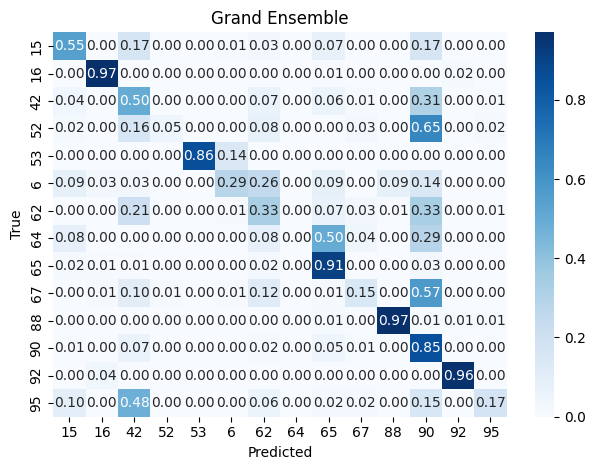

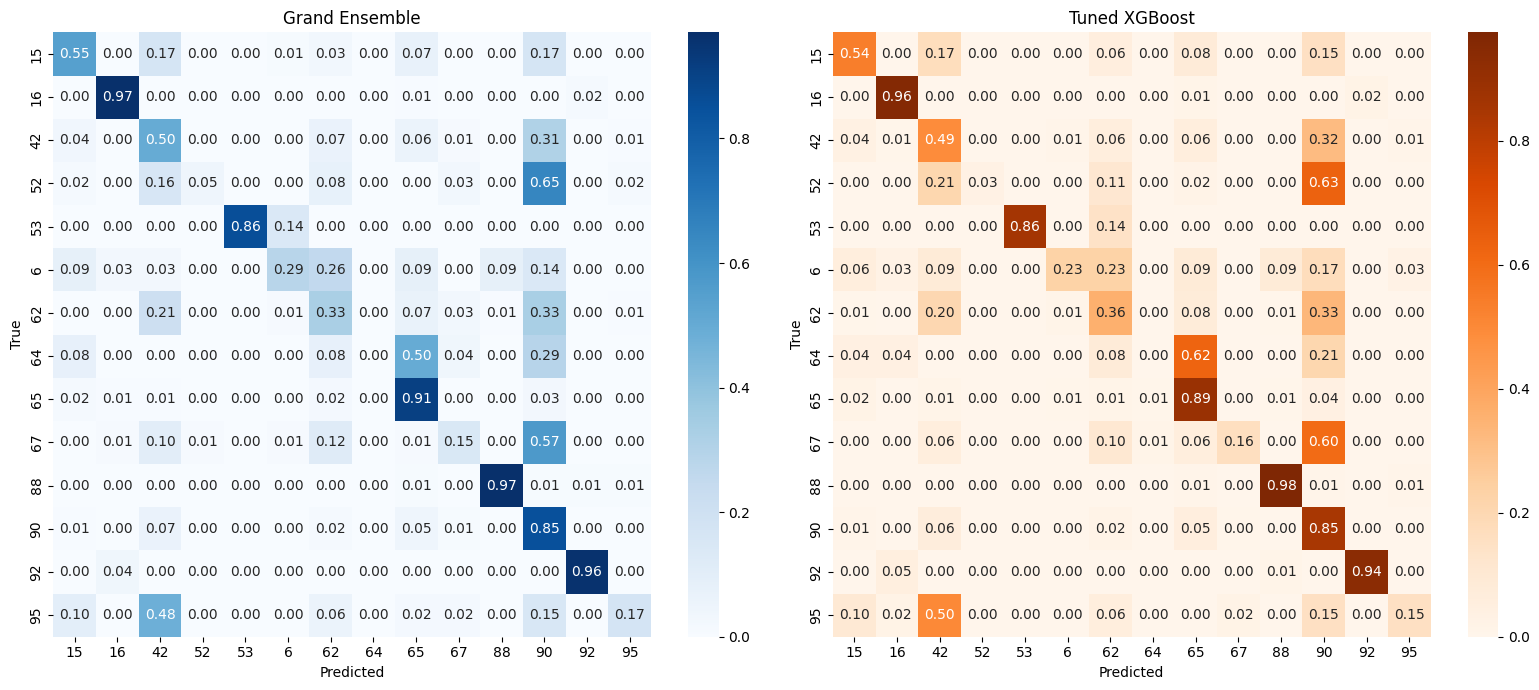

In [23]:
# Confusion matrix of the best model
from src.metrics import plot_confusion_matrix

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Best ensemble
plot_confusion_matrix(y_test, y_pred_grand, class_names, "Grand Ensemble", figsize=None)
plt.sca(axes[0])
from sklearn.metrics import confusion_matrix
import seaborn as sns
cm = confusion_matrix(y_test, y_pred_grand)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2f', xticklabels=class_names,
            yticklabels=class_names, cmap='Blues', ax=axes[0])
axes[0].set_title('Grand Ensemble'); axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')

# Tuned XGBoost
cm2 = confusion_matrix(y_test, y_pred_tuned)
cm2_norm = cm2.astype(float) / cm2.sum(axis=1, keepdims=True)
sns.heatmap(cm2_norm, annot=True, fmt='.2f', xticklabels=class_names,
            yticklabels=class_names, cmap='Oranges', ax=axes[1])
axes[1].set_title('Tuned XGBoost'); axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')

plt.tight_layout()
plt.savefig('figures/chronos_maxout_confmat.pdf', bbox_inches='tight')
plt.show()